# **Figure 2: Correlation Heatmap of Lexical Features and Class Label**

Imports

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Download Benign Domains

In [2]:
cisco_path = kagglehub.dataset_download("adebayo/cisco-umbrella-list")
cisco_path += "/top-1m.csv"
print(cisco_path)

C:\Users\Admin\.cache\kagglehub\datasets\adebayo\cisco-umbrella-list\versions\1/top-1m.csv


Download Malicious DGA Domains

In [3]:
dga_path = kagglehub.dataset_download("gtkcyber/dga-dataset")
dga_path += "/dga_data.csv"
print(dga_path)

C:\Users\Admin\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1/dga_data.csv


Load Datasets

In [4]:
benign_domains = pd.read_csv(cisco_path, header=None)
benign_domains.columns = ["rank", "domain"]
benign_domains["label"] = 0

dga_domains = pd.read_csv(dga_path)
dga_domains["label"] = 1

print("Length of Benign Domain dataset:", len(benign_domains))
print("Length of DGA Domain dataset:", len(dga_domains))

benign_sample = benign_domains[["domain", "label"]]
dga_sample = dga_domains[["domain", "label"]]
df = pd.concat([benign_sample, dga_sample], ignore_index=True)

# Drop any rows with missing domains
print("Missing domains (benign):", benign_sample["domain"].isna().sum())
print("Missing domains (DGA):   ", dga_sample["domain"].isna().sum())
df = df.dropna(subset=["domain"]).reset_index(drop=True)
df["domain"] = df["domain"].astype(str).str.lower()

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Length of Benign Domain dataset: 1000000
Length of DGA Domain dataset: 160000
Missing domains (benign): 0
Missing domains (DGA):    2

Class balance:
label
0    1000000
1     159998
Name: count, dtype: int64
label
0    0.862
1    0.138
Name: proportion, dtype: float64


Extract Features

In [5]:
import math
from collections import Counter

def shannon_entropy(s):
    """Measures randomness of characters in a string. Higher = more random."""
    if not s:
        return 0.0
    counts = Counter(s)
    length = len(s)
    return -sum((c/length) * math.log2(c/length) for c in counts.values())

def vowel_ratio(s):
    if not s:
        return 0.0
    vowels = sum(1 for ch in s if ch in "aeiou")
    letters = sum(1 for ch in s if ch.isalpha())
    return vowels / letters if letters else 0.0

def digit_ratio(s):
    if not s:
        return 0.0
    return sum(1 for ch in s if ch.isdigit()) / len(s)

df["name"]       = df["domain"].str.split(".").str[0]
df["length"]     = df["name"].str.len()
df["entropy"]    = df["name"].apply(shannon_entropy)
df["vowel_ratio"] = df["name"].apply(vowel_ratio)
df["digit_ratio"] = df["name"].apply(digit_ratio)
df["unique_chars"] = df["name"].apply(lambda s: len(set(s)))

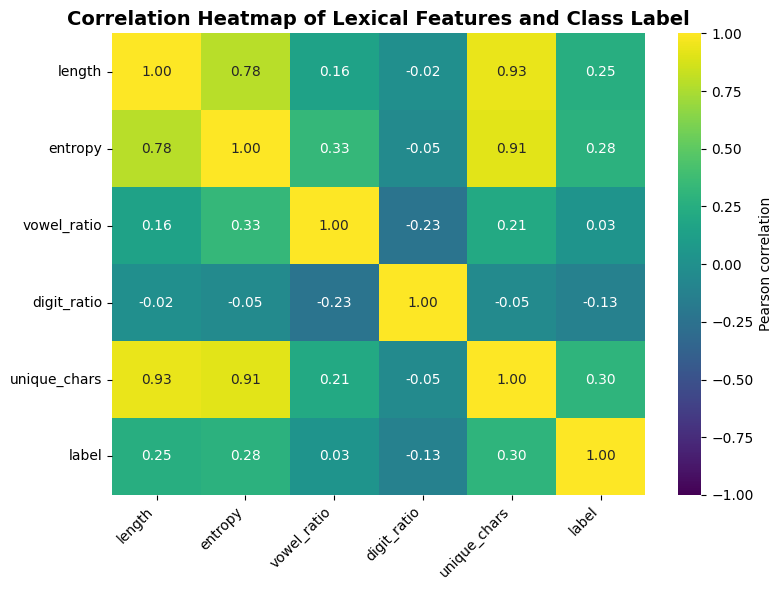

In [6]:
# ==============================
# Feature Correlation Analysis
# ==============================

features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars"]

# Include label so we can see which features correlate with DGA vs benign
corr_cols = features + ["label"]
corr = df[corr_cols].corr()

# --- Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))

labels = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "label"]

sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1,
            ax=ax, cbar_kws={"label": "Pearson correlation"})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title("Correlation Heatmap of Lexical Features and Class Label", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../../figures/features.pdf", format="pdf", bbox_inches="tight")
plt.show()